# 1. PRISM Visual Analytics

**Purpose.** This notebook is a visual analytics report over the results
produced by the PRISM experiment pipeline.


# 2. Imports and Configuration

(Pandas, NumPy, Matplotlib ). Paths are kept relative to the repository root, which is located dynamically by searching upward from the
notebook's working directory for a `results/` folder.


In [1]:

import json
import math
import warnings
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
def find_repo_root(start: Path) -> Path:
    candidates = [start] + list(start.parents)
    for c in candidates:
        if (c / "results").is_dir():
            return c
    return start.parent if start.name == "analysis" else start
REPO_ROOT = find_repo_root(Path.cwd())
RESULTS_DIR = REPO_ROOT / "results"
SUMMARY_DIR = RESULTS_DIR / "summary"
SCORED_DIR = RESULTS_DIR / "scored"
PARSED_DIR = RESULTS_DIR / "parsed"
FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
PROMPT_CONDITIONS = ["P0", "P1", "P2", "P3", "P4"]
print(f"Repository root : {REPO_ROOT}")
print(f"Results dir     : {RESULTS_DIR}  (exists={RESULTS_DIR.is_dir()})")
print(f"Summary dir     : {SUMMARY_DIR}  (exists={SUMMARY_DIR.is_dir()})")
print(f"Figures dir     : {FIGURES_DIR}")


Repository root : n:\college\project\reliability_study
Results dir     : n:\college\project\reliability_study\results  (exists=True)
Summary dir     : n:\college\project\reliability_study\results\summary  (exists=True)
Figures dir     : n:\college\project\reliability_study\results\figures


In [ ]:
from pathlib import Path
import pandas as pd

print("Current working directory:")
print(Path.cwd())
for p in [
    Path.cwd().parent / "results" / "summary"
]:
    print(p, "->", p.exists())
p = Path.cwd()
while p != p.parent:
    candidate = p / "results" / "summary" / "model_prompt_summary.csv"
    print(candidate, "->", candidate.exists())
    if candidate.exists():
        print("\nFOUND:", candidate)
        break
    p = p.parent

Current working directory:
n:\college\project\reliability_study\analysis

Possible result directories:
n:\college\project\reliability_study\analysis\results\summary -> False
n:\college\project\reliability_study\results\summary -> True
n:\college\project\results\summary -> False

Searching upward:
n:\college\project\reliability_study\analysis\results\summary\model_prompt_summary.csv -> False
n:\college\project\reliability_study\results\summary\model_prompt_summary.csv -> True

FOUND: n:\college\project\reliability_study\results\summary\model_prompt_summary.csv


In [3]:

def save_fig(fig, filename, subdir=None):
    out_dir = FIGURES_DIR if subdir is None else (FIGURES_DIR / subdir)
    out_dir.mkdir(parents=True, exist_ok=True)
    path = out_dir / filename
    fig.savefig(path, dpi=150, bbox_inches="tight")
    return path



def model_colors(models):
    cmap = plt.colormaps["tab10" if len(models) <= 10 else "tab20"]
    return {m: cmap(i % cmap.N) for i, m in enumerate(sorted(models))}

def dataset_hatches(datasets):
    hatch_cycle = ["", "//", "xx", "..", "\\\\\\\\", "++"]
    return {d: hatch_cycle[i % len(hatch_cycle)] for i, d in enumerate(sorted(datasets))}

print("Plot helpers ready.")


Plot helpers ready.


# 3. Load and Validate Results


In [4]:

model_dataset_summary_path = SUMMARY_DIR / "model_dataset_summary.csv"
model_prompt_summary_path = SUMMARY_DIR / "model_prompt_summary.csv"
question_metrics_paths = sorted(SUMMARY_DIR.glob("*_question_metrics.jsonl")) if SUMMARY_DIR.is_dir() else []

print("Discovered files:")
print(f"  model_dataset_summary.csv : {'FOUND' if model_dataset_summary_path.is_file() else 'MISSING'}")
print(f"  model_prompt_summary.csv  : {'FOUND' if model_prompt_summary_path.is_file() else 'MISSING'}")
print(f"  *_question_metrics.jsonl  : {len(question_metrics_paths)} file(s)")
for p in question_metrics_paths:
    print(f"      - {p.relative_to(REPO_ROOT)}")


Discovered files:
  model_dataset_summary.csv : FOUND
  model_prompt_summary.csv  : FOUND
  *_question_metrics.jsonl  : 8 file(s)
      - results\summary\arc_challenge__gemma3_4b_question_metrics.jsonl
      - results\summary\arc_challenge__llama3.2_3b_question_metrics.jsonl
      - results\summary\arc_challenge__mistral_7b_question_metrics.jsonl
      - results\summary\arc_challenge__phi4-mini_latest_question_metrics.jsonl
      - results\summary\sciq__gemma3_4b_question_metrics.jsonl
      - results\summary\sciq__llama3.2_3b_question_metrics.jsonl
      - results\summary\sciq__mistral_7b_question_metrics.jsonl
      - results\summary\sciq__phi4-mini_latest_question_metrics.jsonl


In [5]:

MODEL_DATASET_SUMMARY_COLUMNS = [
    "model", "dataset", "n_questions", "expected_prompt_responses", "observed_prompt_responses",
    "missing_prompt_responses", "prompt_response_accuracy", "conditional_accuracy",
    "answer_recovery_rate", "unknown_rate", "instruction_compliance_rate",
    "question_majority_accuracy", "mean_agreement", "mean_prompt_sensitivity",
    "complete_questions", "answer_unanimous_rate", "prompt_invariant_incorrect_rate",
]

if model_dataset_summary_path.is_file():
    df_model_dataset = pd.read_csv(model_dataset_summary_path)
else:
    df_model_dataset = pd.DataFrame(columns=MODEL_DATASET_SUMMARY_COLUMNS)
    warnings.warn("model_dataset_summary.csv not found; model/dataset-level analyses will be skipped.")

df_model_dataset.head()


,model,dataset,n_questions,expected_prompt_responses,observed_prompt_responses,missing_prompt_responses,prompt_response_accuracy,conditional_accuracy,answer_recovery_rate,unknown_rate,instruction_compliance_rate,question_majority_accuracy,mean_agreement,mean_prompt_sensitivity,complete_questions,answer_unanimous_rate,prompt_invariant_incorrect_rate
0,gemma3:4b,arc_challenge,200,1000,1000,0,0.738,0.7380,1.000,0.000,1.000,0.730,0.943,0.057,200,0.790,0.135
1,gemma3:4b,sciq,200,1000,1000,0,0.885,0.8859,0.999,0.001,0.999,0.895,0.974,0.026,200,0.915,0.070
2,llama3.2:3b,arc_challenge,200,1000,1000,0,0.690,0.6914,0.998,0.002,0.913,0.710,0.930,0.070,200,0.735,0.170
3,llama3.2:3b,sciq,200,1000,1000,0,0.884,0.8876,0.996,0.004,0.971,0.895,0.979,0.021,200,0.920,0.075
4,mistral:7b,arc_challenge,200,1000,1000,0,0.731,0.7310,1.000,0.000,0.238,0.735,0.936,0.064,200,0.785,0.155


In [6]:

MODEL_PROMPT_SUMMARY_COLUMNS = [
    "model", "dataset", "prompt_condition", "n_observed", "n_recovered", "n_correct",
    "n_instruction_compliant", "answer_recovery_rate", "accuracy", "conditional_accuracy",
    "instruction_compliant_rate", "unknown_rate",
]

if model_prompt_summary_path.is_file():
    df_model_prompt = pd.read_csv(model_prompt_summary_path)
else:
    df_model_prompt = pd.DataFrame(columns=MODEL_PROMPT_SUMMARY_COLUMNS)
    warnings.warn("model_prompt_summary.csv not found; prompt-condition analyses will be skipped.")

df_model_prompt.head()


,model,dataset,prompt_condition,n_observed,n_recovered,n_correct,n_instruction_compliant,answer_recovery_rate,accuracy,conditional_accuracy,instruction_compliant_rate,unknown_rate
0,gemma3:4b,arc_challenge,P0,200,200,150,200,1.0,0.750,0.750,1.0,0.0
1,gemma3:4b,arc_challenge,P1,200,200,148,200,1.0,0.740,0.740,1.0,0.0
2,gemma3:4b,arc_challenge,P2,200,200,149,200,1.0,0.745,0.745,1.0,0.0
3,gemma3:4b,arc_challenge,P3,200,200,147,200,1.0,0.735,0.735,1.0,0.0
4,gemma3:4b,arc_challenge,P4,200,200,144,200,1.0,0.720,0.720,1.0,0.0


In [7]:

QUESTION_LEVEL_FIELDS = [
    "experiment_id", "protocol_version", "dataset", "question_id", "model", "expected_answer",
    "responses", "prompt_correctness", "prompt_compliance", "prompt_recovery",
    "expected_prompt_count", "observed_prompt_count", "missing_prompt_count",
    "valid_response_count", "unknown_count",
    "answer_recovery_rate", "unknown_rate", "instruction_compliance_rate",
    "correct_response_count", "prompt_response_accuracy", "conditional_accuracy",
    "majority_answer", "majority_count", "agreement", "prompt_sensitivity",
    "answer_unanimous", "majority_correct",
]

def load_question_metrics(paths):
    records = []
    bad_lines = 0
    for p in paths:
        try:
            with open(p, "r") as f:
                for line in f:
                    line = line.strip()
                    if not line:
                        continue
                    try:
                        records.append(json.loads(line))
                    except json.JSONDecodeError:
                        bad_lines += 1
        except OSError as e:
            warnings.warn(f"Could not read {p}: {e}")
    if bad_lines:
        warnings.warn(f"Skipped {bad_lines} malformed JSONL line(s).")
    return pd.DataFrame.from_records(records)

df_question = load_question_metrics(question_metrics_paths)
if df_question.empty:
    warnings.warn("No question-level records loaded; question-level analyses will be skipped.")

print(f"Loaded {len(df_question)} question-level records.")
df_question.head()


Loaded 1600 question-level records.


,experiment_id,protocol_version,dataset,question_id,model,expected_answer,responses,prompt_correctness,prompt_compliance,prompt_recovery,expected_prompt_count,observed_prompt_count,missing_prompt_count,valid_response_count,unknown_count,answer_recovery_rate,unknown_rate,instruction_compliance_rate,correct_response_count,prompt_response_accuracy,conditional_accuracy,majority_answer,majority_count,agreement,prompt_sensitivity,answer_unanimous,majority_correct
0,PRISM-EXP1-v1,1.0,arc_challenge,ACTAAP_2009_7_8,gemma3:4b,D,"{'P0': 'D', 'P1': 'D', 'P2': 'D', 'P3': 'D', '...","{'P0': True, 'P1': True, 'P2': True, 'P3': Tru...","{'P0': True, 'P1': True, 'P2': True, 'P3': Tru...","{'P0': True, 'P1': True, 'P2': True, 'P3': Tru...",5,5,0,5,0,1.0,0.0,1.0,5,1.0,1.0,D,5,1.0,0.0,True,True
1,PRISM-EXP1-v1,1.0,arc_challenge,ACTAAP_2010_7_14,gemma3:4b,C,"{'P0': 'C', 'P1': 'C', 'P2': 'C', 'P3': 'C', '...","{'P0': True, 'P1': True, 'P2': True, 'P3': Tru...","{'P0': True, 'P1': True, 'P2': True, 'P3': Tru...","{'P0': True, 'P1': True, 'P2': True, 'P3': Tru...",5,5,0,5,0,1.0,0.0,1.0,5,1.0,1.0,C,5,1.0,0.0,True,True
2,PRISM-EXP1-v1,1.0,arc_challenge,ACTAAP_2014_7_3,gemma3:4b,D,"{'P0': 'D', 'P1': 'D', 'P2': 'D', 'P3': 'D', '...","{'P0': True, 'P1': True, 'P2': True, 'P3': Tru...","{'P0': True, 'P1': True, 'P2': True, 'P3': Tru...","{'P0': True, 'P1': True, 'P2': True, 'P3': Tru...",5,5,0,5,0,1.0,0.0,1.0,5,1.0,1.0,D,5,1.0,0.0,True,True
3,PRISM-EXP1-v1,1.0,arc_challenge,AKDE&ED_2008_4_25,gemma3:4b,A,"{'P0': 'D', 'P1': 'D', 'P2': 'D', 'P3': 'A', '...","{'P0': False, 'P1': False, 'P2': False, 'P3': ...","{'P0': True, 'P1': True, 'P2': True, 'P3': Tru...","{'P0': True, 'P1': True, 'P2': True, 'P3': Tru...",5,5,0,5,0,1.0,0.0,1.0,1,0.2,0.2,D,4,0.8,0.2,False,False
4,PRISM-EXP1-v1,1.0,arc_challenge,AKDE&ED_2008_8_53,gemma3:4b,C,"{'P0': 'C', 'P1': 'C', 'P2': 'C', 'P3': 'C', '...","{'P0': True, 'P1': True, 'P2': True, 'P3': Tru...","{'P0': True, 'P1': True, 'P2': True, 'P3': Tru...","{'P0': True, 'P1': True, 'P2': True, 'P3': Tru...",5,5,0,5,0,1.0,0.0,1.0,5,1.0,1.0,C,5,1.0,0.0,True,True


In [8]:

validation_notes = []

def check(label, ok, detail=""):
    status = "OK" if ok else "WARN"
    validation_notes.append((status, label, detail))
if not df_model_dataset.empty:
    missing_cols = [c for c in MODEL_DATASET_SUMMARY_COLUMNS if c not in df_model_dataset.columns]
    check("model_dataset_summary.csv has all required columns", len(missing_cols) == 0,
          f"missing: {missing_cols}" if missing_cols else "")
    numeric_cols = [c for c in MODEL_DATASET_SUMMARY_COLUMNS
                    if c not in ("model", "dataset") and c in df_model_dataset.columns]
    for c in numeric_cols:
        coerced = pd.to_numeric(df_model_dataset[c], errors="coerce")
        n_bad = coerced.isna().sum() - df_model_dataset[c].isna().sum()
        check(f"model_dataset_summary.{c} is numeric", n_bad == 0,
              f"{n_bad} non-numeric value(s)" if n_bad else "")
        df_model_dataset[c] = coerced
    n_null = df_model_dataset.isna().sum().sum()
    check("model_dataset_summary.csv missing-value count", True, f"{n_null} null cell(s) present (see below)")
else:
    check("model_dataset_summary.csv loaded", False, "file missing or empty")
if not df_model_prompt.empty:
    missing_cols = [c for c in MODEL_PROMPT_SUMMARY_COLUMNS if c not in df_model_prompt.columns]
    check("model_prompt_summary.csv has all required columns", len(missing_cols) == 0,
          f"missing: {missing_cols}" if missing_cols else "")
    bad_prompts = sorted(set(df_model_prompt.get("prompt_condition", pd.Series(dtype=str))) - set(PROMPT_CONDITIONS))
    check("model_prompt_summary.prompt_condition values are within P0-P4", len(bad_prompts) == 0,
          f"unexpected values: {bad_prompts}" if bad_prompts else "")
    numeric_cols = [c for c in MODEL_PROMPT_SUMMARY_COLUMNS
                    if c not in ("model", "dataset", "prompt_condition") and c in df_model_prompt.columns]
    for c in numeric_cols:
        coerced = pd.to_numeric(df_model_prompt[c], errors="coerce")
        n_bad = coerced.isna().sum() - df_model_prompt[c].isna().sum()
        check(f"model_prompt_summary.{c} is numeric", n_bad == 0,
              f"{n_bad} non-numeric value(s)" if n_bad else "")
        df_model_prompt[c] = coerced
else:
    check("model_prompt_summary.csv loaded", False, "file missing or empty")
if not df_question.empty:
    missing_fields = [c for c in QUESTION_LEVEL_FIELDS if c not in df_question.columns]
    check("question-level records have all required fields", len(missing_fields) == 0,
          f"missing: {missing_fields}" if missing_fields else "")

    def _dict_keys_ok(d):
        return isinstance(d, dict) and set(d.keys()) <= set(PROMPT_CONDITIONS)

    if "responses" in df_question.columns:
        ok = df_question["responses"].dropna().apply(_dict_keys_ok).all()
        check("question-level 'responses' dict keys are within P0-P4", bool(ok))
    for numeric_field in ["agreement", "prompt_sensitivity", "answer_recovery_rate", "unknown_rate",
                           "instruction_compliance_rate", "prompt_response_accuracy", "conditional_accuracy"]:
        if numeric_field in df_question.columns:
            coerced = pd.to_numeric(df_question[numeric_field], errors="coerce")
            n_bad = coerced.isna().sum() - df_question[numeric_field].isna().sum()
            check(f"question-level.{numeric_field} is numeric", n_bad == 0,
                  f"{n_bad} non-numeric value(s)" if n_bad else "")
            df_question[numeric_field] = coerced
else:
    check("question-level JSONL records loaded", False, "no files found or all empty")

# --- cross-check that model/dataset combinations are not silently dropped ------
if not df_model_dataset.empty and not df_question.empty:
    agg_combos = set(zip(df_model_dataset["model"], df_model_dataset["dataset"]))
    q_combos = set(zip(df_question["model"], df_question["dataset"]))
    only_in_agg = agg_combos - q_combos
    only_in_q = q_combos - agg_combos
    check("model/dataset combos match between aggregate and question-level files",
          len(only_in_agg) == 0 and len(only_in_q) == 0,
          f"only in aggregate: {only_in_agg}; only in question-level: {only_in_q}")

print("Validation summary")
print("=" * 70)
for status, label, detail in validation_notes:
    line = f"[{status}] {label}"
    if detail:
        line += f" -- {detail}"
    print(line)


Validation summary
[OK] model_dataset_summary.csv has all required columns
[OK] model_dataset_summary.n_questions is numeric
[OK] model_dataset_summary.expected_prompt_responses is numeric
[OK] model_dataset_summary.observed_prompt_responses is numeric
[OK] model_dataset_summary.missing_prompt_responses is numeric
[OK] model_dataset_summary.prompt_response_accuracy is numeric
[OK] model_dataset_summary.conditional_accuracy is numeric
[OK] model_dataset_summary.answer_recovery_rate is numeric
[OK] model_dataset_summary.unknown_rate is numeric
[OK] model_dataset_summary.instruction_compliance_rate is numeric
[OK] model_dataset_summary.question_majority_accuracy is numeric
[OK] model_dataset_summary.mean_agreement is numeric
[OK] model_dataset_summary.mean_prompt_sensitivity is numeric
[OK] model_dataset_summary.complete_questions is numeric
[OK] model_dataset_summary.answer_unanimous_rate is numeric
[OK] model_dataset_summary.prompt_invariant_incorrect_rate is numeric
[OK] model_dataset_

# 4. Overall Model Performance

**Level:** model/dataset aggregate (`model_dataset_summary.csv`).

Two complementary accuracy measures are shown side by side:

- `prompt_response_accuracy`:  accuracy at the level of individual prompt *responses*
  (correct recovered answers / observed prompt responses). This treats every prompt
  condition's response as its own data point.
- `question_majority_accuracy`: accuracy at the level of *questions*, using the majority
  recovered answer across the five prompt conditions for each question.

Comparing the two shows whether taking a majority vote across prompt conditions recovers
correctness that individual prompt responses miss (majority accuracy higher), or whether it
makes little difference.


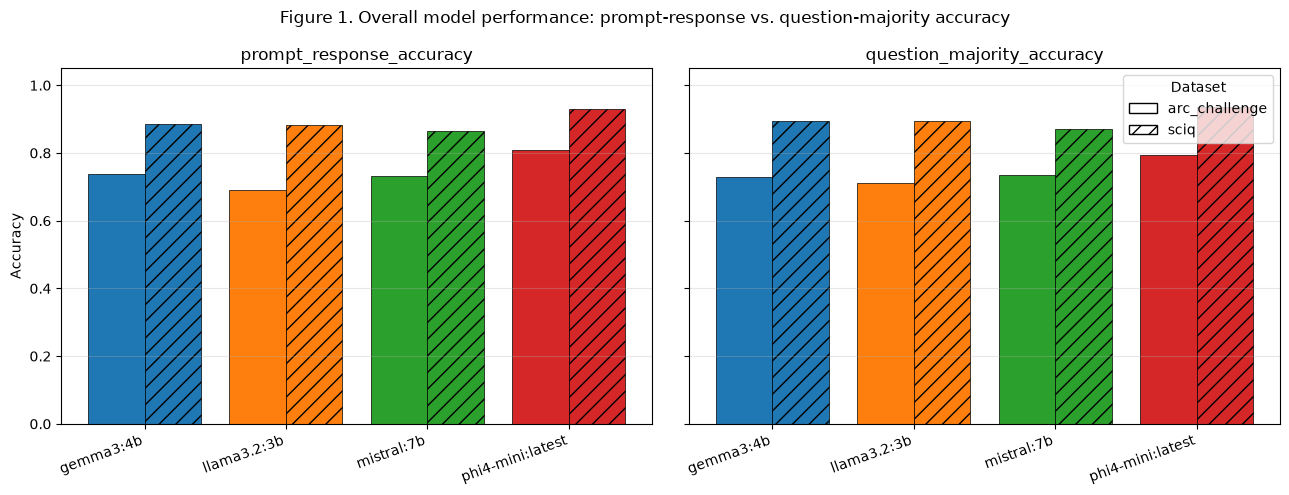

In [ ]:

if df_model_dataset.empty:
    print("Skipping Figure 1: model_dataset_summary.csv not available.")
else:
    models = sorted(df_model_dataset["model"].unique())
    datasets = sorted(df_model_dataset["dataset"].unique())
    colors = model_colors(models)
    hatches = dataset_hatches(datasets)
    metrics = ["prompt_response_accuracy", "question_majority_accuracy"]

    fig, axes = plt.subplots(1, len(metrics), figsize=(6.5 * len(metrics), 5), sharey=True)
    if len(metrics) == 1:
        axes = [axes]

    bar_width = 0.8 / max(len(datasets), 1)
    x = np.arange(len(models))

    for ax, metric in zip(axes, metrics):
        for j, ds in enumerate(datasets):
            sub = df_model_dataset[df_model_dataset["dataset"] == ds].set_index("model")
            vals = [sub[metric].get(m, np.nan) for m in models]
            offsets = x + (j - (len(datasets) - 1) / 2) * bar_width
            ax.bar(offsets, vals, width=bar_width,
                   color=[colors[m] for m in models], edgecolor="black", linewidth=0.5,
                   hatch=hatches[ds], label=ds)
        ax.set_xticks(x)
        ax.set_xticklabels(models, rotation=20, ha="right")
        ax.set_title(metric)
        ax.set_ylim(0, 1.05)
        ax.set_ylabel("Accuracy" if ax is axes[0] else "")
        ax.grid(axis="y", alpha=0.3)

    from matplotlib.patches import Patch
    dataset_handles = [Patch(facecolor="white", edgecolor="black", hatch=hatches[d], label=d) for d in datasets]
    axes[-1].legend(handles=dataset_handles, title="Dataset", loc="upper right")

    fig.suptitle("Figure 1. Overall model performance: prompt-response vs. question-majority accuracy")
    fig.tight_layout()
    save_fig(fig, "model_accuracy.png")
    plt.show()


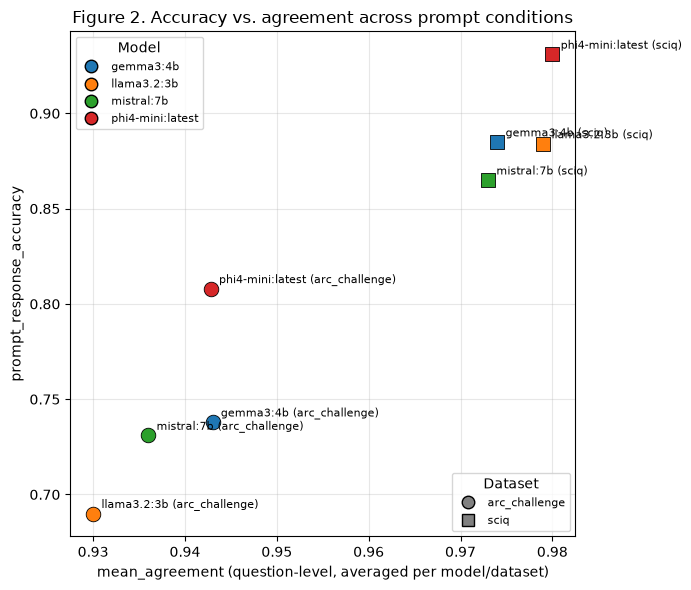

In [10]:

if df_model_dataset.empty:
    print("Skipping Figure 2: model_dataset_summary.csv not available.")
else:
    models = sorted(df_model_dataset["model"].unique())
    datasets = sorted(df_model_dataset["dataset"].unique())
    colors = model_colors(models)
    marker_cycle = ["o", "s", "^", "D", "v", "P", "X"]
    dataset_markers = {d: marker_cycle[i % len(marker_cycle)] for i, d in enumerate(datasets)}

    fig, ax = plt.subplots(figsize=(7, 6))
    for _, row in df_model_dataset.iterrows():
        ax.scatter(row["mean_agreement"], row["prompt_response_accuracy"],
                    color=colors[row["model"]], marker=dataset_markers[row["dataset"]],
                    s=110, edgecolor="black", linewidth=0.6, zorder=3)
        ax.annotate(f'{row["model"]} ({row["dataset"]})',
                    (row["mean_agreement"], row["prompt_response_accuracy"]),
                    textcoords="offset points", xytext=(6, 4), fontsize=8)

    ax.set_xlabel("mean_agreement (question-level, averaged per model/dataset)")
    ax.set_ylabel("prompt_response_accuracy")
    ax.set_title("Figure 2. Accuracy vs. agreement across prompt conditions")
    ax.grid(alpha=0.3)

    from matplotlib.lines import Line2D
    model_handles = [Line2D([0], [0], marker="o", color="w", markerfacecolor=colors[m],
                             markeredgecolor="black", markersize=9, label=m) for m in models]
    dataset_handles = [Line2D([0], [0], marker=dataset_markers[d], color="w", markerfacecolor="grey",
                               markeredgecolor="black", markersize=9, label=d) for d in datasets]
    leg1 = ax.legend(handles=model_handles, title="Model", loc="upper left", fontsize=8)
    ax.add_artist(leg1)
    ax.legend(handles=dataset_handles, title="Dataset", loc="lower right", fontsize=8)

    fig.tight_layout()
    save_fig(fig, "accuracy_vs_agreement.png")
    plt.show()


**Interpretation.** Figure 2 places each model/dataset combination on a plane of
"how much prompt conditions agree with each other" (x-axis) versus "how often the recovered
answer is correct" (y-axis). Points high and to the right indicate models that are both
accurate and consistent across prompt phrasing. Points low and to the right indicate models
that are *consistent but not necessarily correct* — i.e., possible prompt-invariant
incorrectness (examined directly in Figure 7). This is a descriptive scatter; no regression
or correlation test is fit here beyond what is reported in the Key Observations section.


# 5. Prompt-Condition Analysis

**Level:** prompt-level (`model_prompt_summary.csv`), one row per `(model, dataset,
prompt_condition)`.

Figure 3 shows `accuracy` for each of the five prompt conditions (P0-P4), grouped by model,
with a separate panel per dataset so datasets are never mixed within a single set of bars.


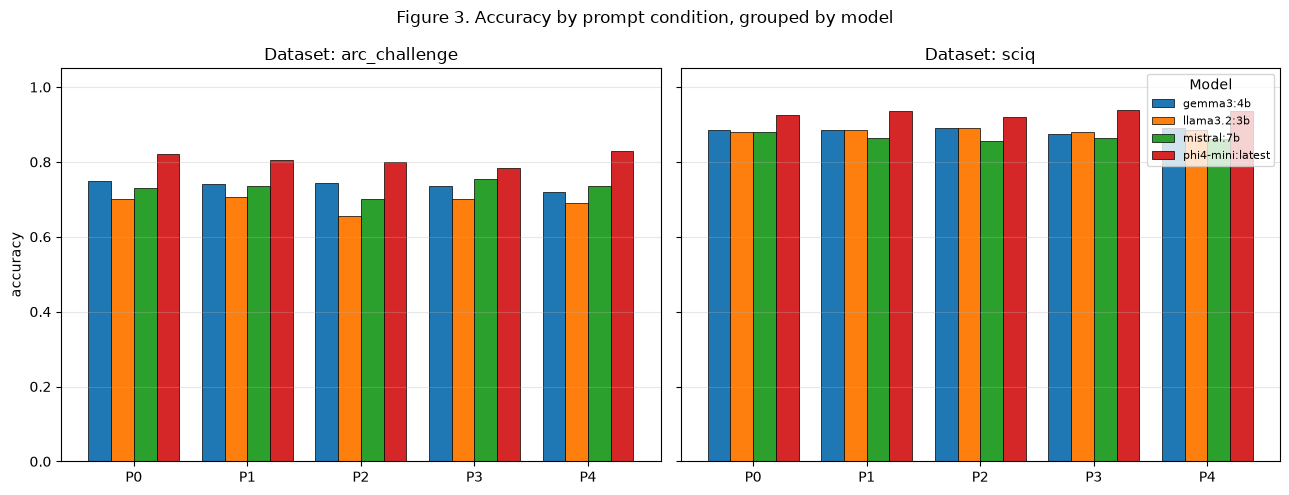

In [ ]:

if df_model_prompt.empty:
    print("Skipping Figure 3: model_prompt_summary.csv not available.")
else:
    datasets = sorted(df_model_prompt["dataset"].unique())
    models = sorted(df_model_prompt["model"].unique())
    colors = model_colors(models)
    present_prompts = [p for p in PROMPT_CONDITIONS if p in set(df_model_prompt["prompt_condition"])]
    x = np.arange(len(present_prompts))
    bar_width = 0.8 / max(len(models), 1)

    fig, axes = plt.subplots(1, len(datasets), figsize=(6.5 * len(datasets), 5), sharey=True)
    if len(datasets) == 1:
        axes = [axes]

    for ax, ds in zip(axes, datasets):
        sub_ds = df_model_prompt[df_model_prompt["dataset"] == ds]
        for i, m in enumerate(models):
            sub = sub_ds[sub_ds["model"] == m].set_index("prompt_condition")
            vals = [sub["accuracy"].get(p, np.nan) for p in present_prompts]
            offsets = x + (i - (len(models) - 1) / 2) * bar_width
            ax.bar(offsets, vals, width=bar_width, color=colors[m], edgecolor="black",
                   linewidth=0.5, label=m)
        ax.set_xticks(x)
        ax.set_xticklabels(present_prompts)
        ax.set_title(f"Dataset: {ds}")
        ax.set_ylim(0, 1.05)
        ax.set_ylabel("accuracy" if ax is axes[0] else "")
        ax.grid(axis="y", alpha=0.3)

    axes[-1].legend(title="Model", fontsize=8, loc="upper right")
    fig.suptitle("Figure 3. Accuracy by prompt condition, grouped by model")
    fig.tight_layout()
    save_fig(fig, "prompt_accuracy.png")
    plt.show()


**Interpretation.** Each panel is one dataset. Within a panel, bars are grouped by prompt
condition (P0-P4) and colored by model. Flat profiles across P0-P4 for a given model indicate
that the model's accuracy is not sensitive to how the question is phrased; large swings
indicate prompt sensitivity at the accuracy level (distinct from the agreement-based prompt
sensitivity metric examined in Section 6).


# 6. Consistency and Prompt Sensitivity

**Level:** question-level (`*_question_metrics.jsonl`).

`agreement` and `prompt_sensitivity` (`= 1 - agreement`) are computed per question and describe
how much the five prompt conditions agree with each other on that question, independent of
whether the agreed-upon answer is correct. This section shows the full distribution (not just
the mean) via box plots, and then a separate descriptive analysis of pairwise agreement between
specific prompt condition pairs (Figure 8).


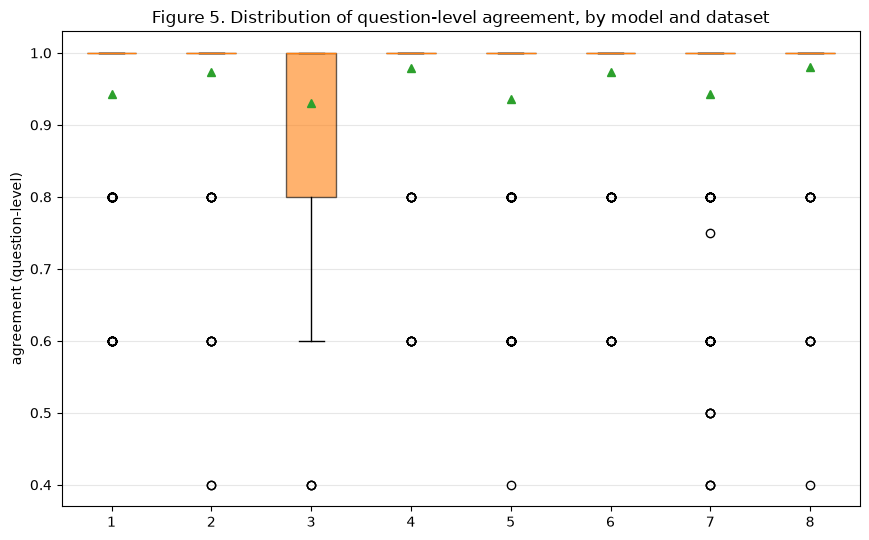

In [15]:

if df_question.empty or "agreement" not in df_question.columns:
    print("Skipping Figure 5: question-level 'agreement' field not available.")
else:
    groups = sorted(df_question.dropna(subset=["agreement"])
                     .groupby(["model", "dataset"]).groups.keys())
    data = [df_question[(df_question["model"] == m) & (df_question["dataset"] == d)]["agreement"].dropna().values
            for m, d in groups]
    labels = [f"{m}\n{d}" for m, d in groups]

    fig, ax = plt.subplots(figsize=(max(7, 1.1 * len(groups)), 5.5))
    bp = ax.boxplot(data, showmeans=True, patch_artist=True)
    models_here = sorted(set(m for m, d in groups))
    colors = model_colors(models_here)
    for patch, (m, d) in zip(bp["boxes"], groups):
        patch.set_facecolor(colors[m])
        patch.set_alpha(0.6)

    ax.set_ylabel("agreement (question-level)")
    ax.set_title("Figure 5. Distribution of question-level agreement, by model and dataset")
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    save_fig(fig, "agreement_distribution.png")
    plt.show()


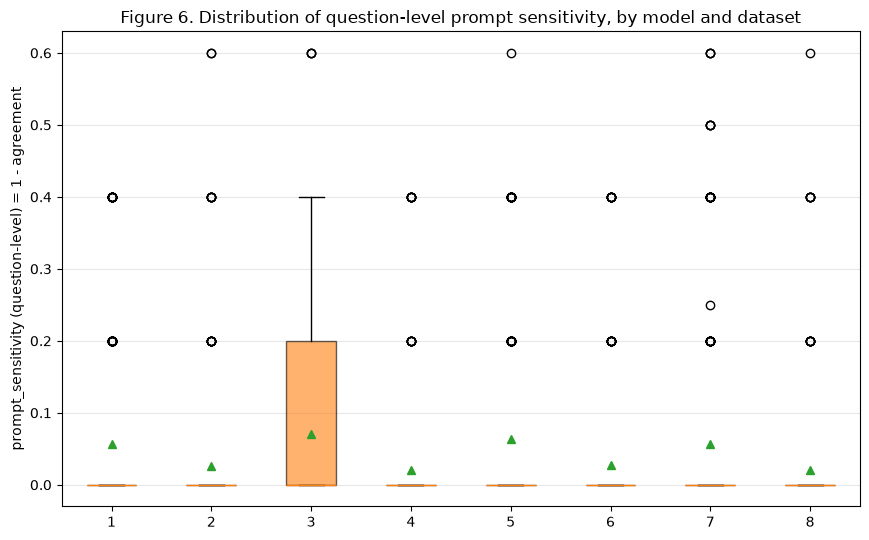

In [17]:

if df_question.empty or "prompt_sensitivity" not in df_question.columns:
    print("Skipping Figure 6: question-level 'prompt_sensitivity' field not available.")
else:
    groups = sorted(df_question.dropna(subset=["prompt_sensitivity"])
                     .groupby(["model", "dataset"]).groups.keys())
    data = [df_question[(df_question["model"] == m) & (df_question["dataset"] == d)]["prompt_sensitivity"].dropna().values
            for m, d in groups]
    labels = [f"{m}\n{d}" for m, d in groups]

    fig, ax = plt.subplots(figsize=(max(7, 1.1 * len(groups)), 5.5))
    bp = ax.boxplot(data, showmeans=True, patch_artist=True)
    models_here = sorted(set(m for m, d in groups))
    colors = model_colors(models_here)
    for patch, (m, d) in zip(bp["boxes"], groups):
        patch.set_facecolor(colors[m])
        patch.set_alpha(0.6)

    ax.set_ylabel("prompt_sensitivity (question-level) = 1 - agreement")
    ax.set_title("Figure 6. Distribution of question-level prompt sensitivity, by model and dataset")
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    save_fig(fig, "prompt_sensitivity_distribution.png")
    plt.show()


**Interpretation (Figures 5-6).** These box plots show the full spread of question-level
agreement / prompt sensitivity, not just the aggregate mean reported in
`model_dataset_summary.csv`. A tall box or long whiskers indicate that a model's sensitivity to
prompt phrasing varies substantially from question to question, which the mean alone would
hide. `prompt_sensitivity` is used exactly as provided (`1 - agreement`); it is not
recomputed here.


### Pairwise prompt agreement (Figure 8)

**Level:** question-level, aggregated into a descriptive `model x dataset` matrix.

This is a separate descriptive analysis and is **not** a redefinition of `prompt_sensitivity`.
For each `(model, dataset)` combination, and for every pair of prompt conditions `(P_i, P_j)`,
we compute:

```
pairwise agreement(P_i, P_j) =
    (# questions where both P_i and P_j produced a recovered answer AND those answers are equal)
    / (# questions where both P_i and P_j produced a recovered answer)
```

using the `responses` dictionary directly (an entry is only used if it corresponds to a
recovered A/B/C/D answer, i.e. not missing/unknown). If a pair has zero comparable recovered
responses, the cell is left as `NaN` rather than assigned an arbitrary value.


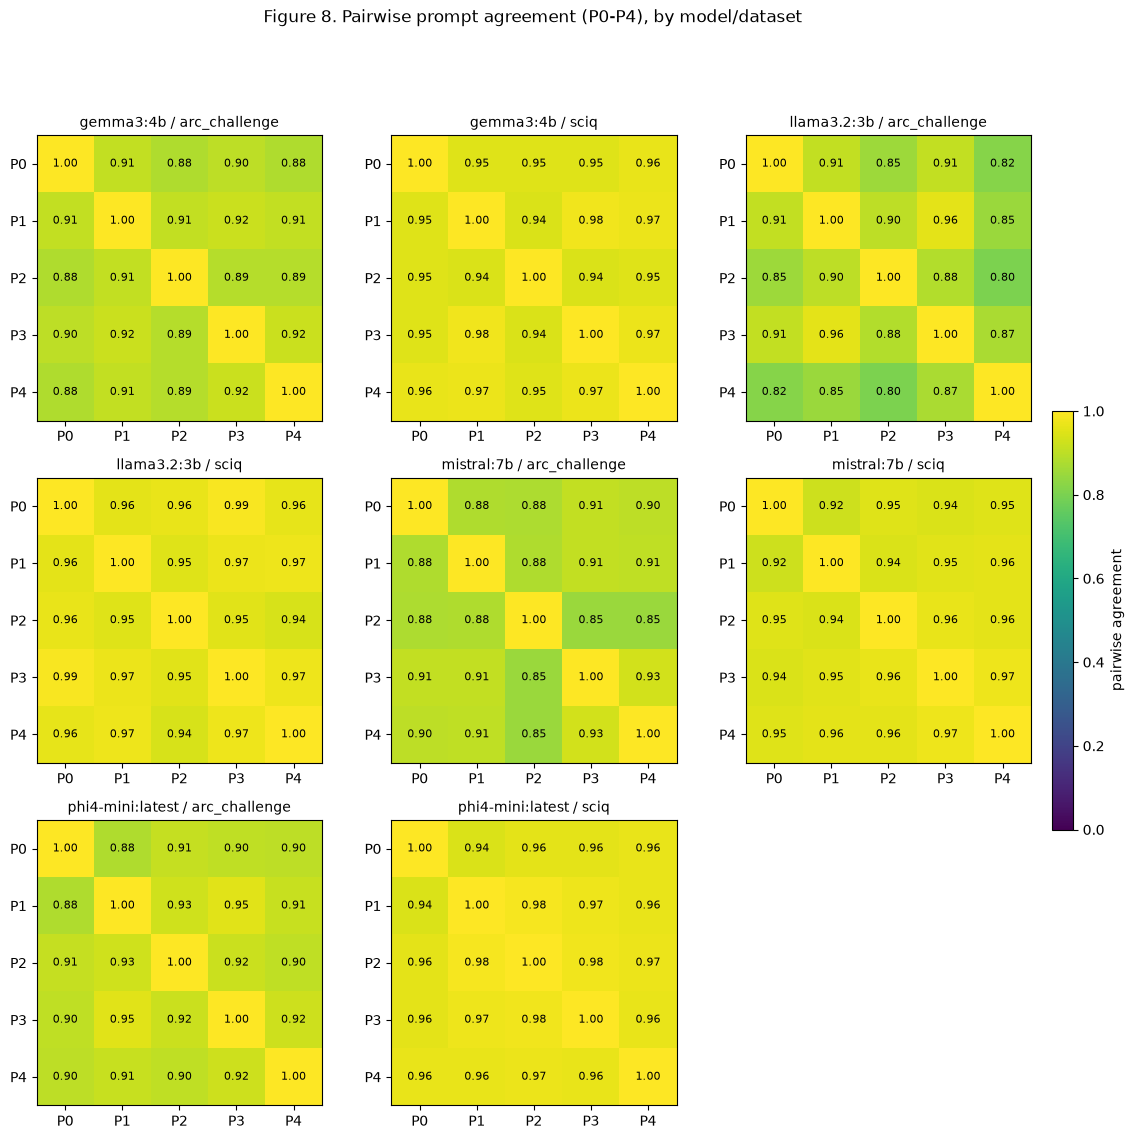

In [18]:

VALID_ANSWERS = {"A", "B", "C", "D"}

def pairwise_agreement_matrix(sub_df, prompts=PROMPT_CONDITIONS):
    n = len(prompts)
    mat = np.full((n, n), np.nan)
    if "responses" not in sub_df.columns:
        return mat
    resp_series = sub_df["responses"].dropna()
    for i, pi in enumerate(prompts):
        for j, pj in enumerate(prompts):
            if i == j:
                mat[i, j] = 1.0
                continue
            comparable = 0
            agree = 0
            for resp in resp_series:
                if not isinstance(resp, dict):
                    continue
                ai = resp.get(pi)
                aj = resp.get(pj)
                if ai in VALID_ANSWERS and aj in VALID_ANSWERS:
                    comparable += 1
                    if ai == aj:
                        agree += 1
            mat[i, j] = (agree / comparable) if comparable > 0 else np.nan
    return mat

if df_question.empty or "responses" not in df_question.columns:
    print("Skipping Figure 8: question-level 'responses' field not available.")
else:
    combos = sorted(df_question.groupby(["model", "dataset"]).groups.keys())
    n_combos = len(combos)
    n_cols = min(3, n_combos) if n_combos else 1
    n_rows = math.ceil(n_combos / n_cols) if n_combos else 1

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 4.2 * n_rows), squeeze=False)

    for idx, (m, d) in enumerate(combos):
        r, c = divmod(idx, n_cols)
        ax = axes[r][c]
        sub = df_question[(df_question["model"] == m) & (df_question["dataset"] == d)]
        mat = pairwise_agreement_matrix(sub)

        im = ax.imshow(mat, vmin=0, vmax=1, cmap="viridis")
        ax.set_xticks(range(len(PROMPT_CONDITIONS)))
        ax.set_yticks(range(len(PROMPT_CONDITIONS)))
        ax.set_xticklabels(PROMPT_CONDITIONS)
        ax.set_yticklabels(PROMPT_CONDITIONS)
        ax.set_title(f"{m} / {d}", fontsize=10)
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                val = mat[i, j]
                text = "NaN" if np.isnan(val) else f"{val:.2f}"
                ax.text(j, i, text, ha="center", va="center",
                        color="white" if (not np.isnan(val) and val < 0.6) else "black", fontsize=8)

        # save an individual heatmap file per model/dataset too
        fig_single, ax_single = plt.subplots(figsize=(4.5, 4.2))
        im_single = ax_single.imshow(mat, vmin=0, vmax=1, cmap="viridis")
        ax_single.set_xticks(range(len(PROMPT_CONDITIONS)))
        ax_single.set_yticks(range(len(PROMPT_CONDITIONS)))
        ax_single.set_xticklabels(PROMPT_CONDITIONS)
        ax_single.set_yticklabels(PROMPT_CONDITIONS)
        ax_single.set_title(f"Pairwise prompt agreement: {m} / {d}")
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                val = mat[i, j]
                text = "NaN" if np.isnan(val) else f"{val:.2f}"
                ax_single.text(j, i, text, ha="center", va="center",
                                color="white" if (not np.isnan(val) and val < 0.6) else "black", fontsize=8)
        fig_single.colorbar(im_single, ax=ax_single, fraction=0.046, pad=0.04)
        fig_single.tight_layout()
        safe_m = str(m).replace("/", "_").replace(" ", "_")
        safe_d = str(d).replace("/", "_").replace(" ", "_")
        save_fig(fig_single, f"prompt_agreement_heatmap_{safe_m}_{safe_d}.png", subdir="heatmaps")
        plt.close(fig_single)

    for idx in range(n_combos, n_rows * n_cols):
        r, c = divmod(idx, n_cols)
        axes[r][c].axis("off")

    fig.suptitle("Figure 8. Pairwise prompt agreement (P0-P4), by model/dataset")
    fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02, label="pairwise agreement")
    save_fig(fig, "prompt_agreement_heatmaps_overview.png")
    plt.show()


**Interpretation.** Each heatmap cell is the fraction of questions where two specific
prompt conditions agree, restricted to questions where both conditions produced a recoverable
answer. The diagonal is trivially 1.0. Off-diagonal values close to 1.0 indicate that a
particular pair of prompt phrasings is behaviorally interchangeable for that model/dataset;
lower values highlight specific prompt pairs that drive disagreement, which the single
`mean_agreement` / `prompt_sensitivity` scalar cannot show. `NaN` cells indicate no comparable
recovered-answer pairs were available and are left unfilled rather than estimated.


# 7. Instruction Compliance

**Level:** prompt-level (`model_prompt_summary.csv`), field `instruction_compliant_rate`.

Instruction compliance measures whether a response obeyed the required "return only the
letter" output format. It is **not** the same as answer recovery (whether an A/B/C/D answer
could be extracted at all) and it is **not** the same as correctness. A response can be
non-compliant with the format yet still yield a recoverable, correct answer, or vice versa;
those relationships are not assumed here, only the compliance rate itself is shown.


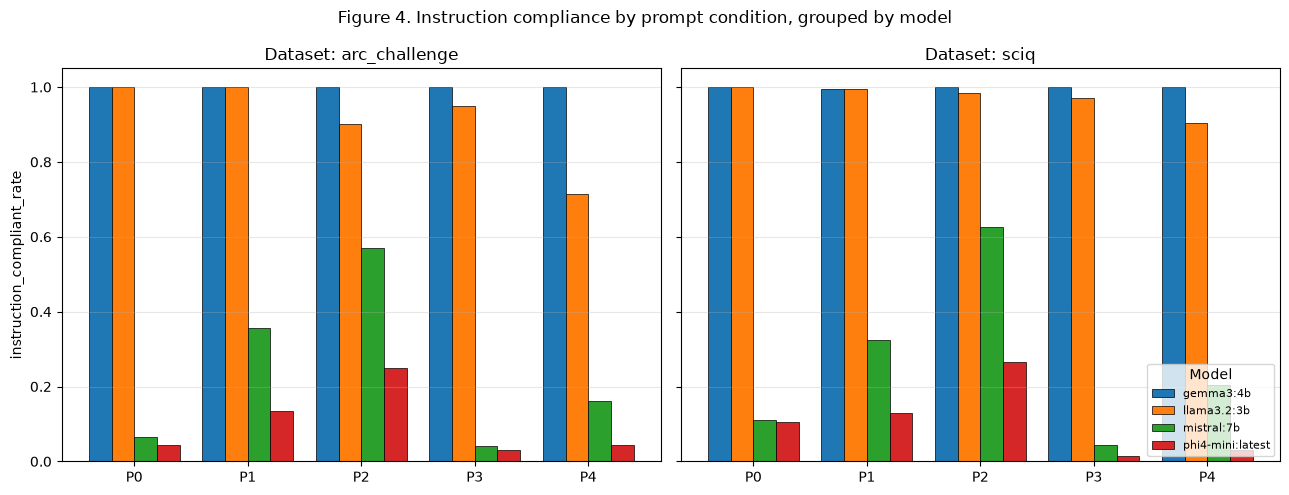

In [19]:

if df_model_prompt.empty or "instruction_compliant_rate" not in df_model_prompt.columns:
    print("Skipping Figure 4: model_prompt_summary.csv or instruction_compliant_rate not available.")
else:
    datasets = sorted(df_model_prompt["dataset"].unique())
    models = sorted(df_model_prompt["model"].unique())
    colors = model_colors(models)
    present_prompts = [p for p in PROMPT_CONDITIONS if p in set(df_model_prompt["prompt_condition"])]
    x = np.arange(len(present_prompts))
    bar_width = 0.8 / max(len(models), 1)

    fig, axes = plt.subplots(1, len(datasets), figsize=(6.5 * len(datasets), 5), sharey=True)
    if len(datasets) == 1:
        axes = [axes]

    for ax, ds in zip(axes, datasets):
        sub_ds = df_model_prompt[df_model_prompt["dataset"] == ds]
        for i, m in enumerate(models):
            sub = sub_ds[sub_ds["model"] == m].set_index("prompt_condition")
            vals = [sub["instruction_compliant_rate"].get(p, np.nan) for p in present_prompts]
            offsets = x + (i - (len(models) - 1) / 2) * bar_width
            ax.bar(offsets, vals, width=bar_width, color=colors[m], edgecolor="black",
                   linewidth=0.5, label=m)
        ax.set_xticks(x)
        ax.set_xticklabels(present_prompts)
        ax.set_title(f"Dataset: {ds}")
        ax.set_ylim(0, 1.05)
        ax.set_ylabel("instruction_compliant_rate" if ax is axes[0] else "")
        ax.grid(axis="y", alpha=0.3)

    axes[-1].legend(title="Model", fontsize=8, loc="lower right")
    fig.suptitle("Figure 4. Instruction compliance by prompt condition, grouped by model")
    fig.tight_layout()
    save_fig(fig, "instruction_compliance.png")
    plt.show()


**Interpretation.** Low bars indicate prompt conditions/models that frequently ignore the
"return only the letter" instruction. This is reported purely as a format-compliance measure;
it does not by itself imply the underlying answer was wrong (see Section 4 and 8 for
correctness-related metrics computed independently).


# 8. Prompt-Invariant Incorrectness

**Level:** model/dataset aggregate, field `prompt_invariant_incorrect_rate` from
`model_dataset_summary.csv` — the fraction of *complete* questions where all five prompt
conditions gave the same recovered answer and that answer was incorrect. This identifies
questions a model gets reliably, consistently wrong regardless of prompt phrasing (as opposed
to being merely inconsistent).


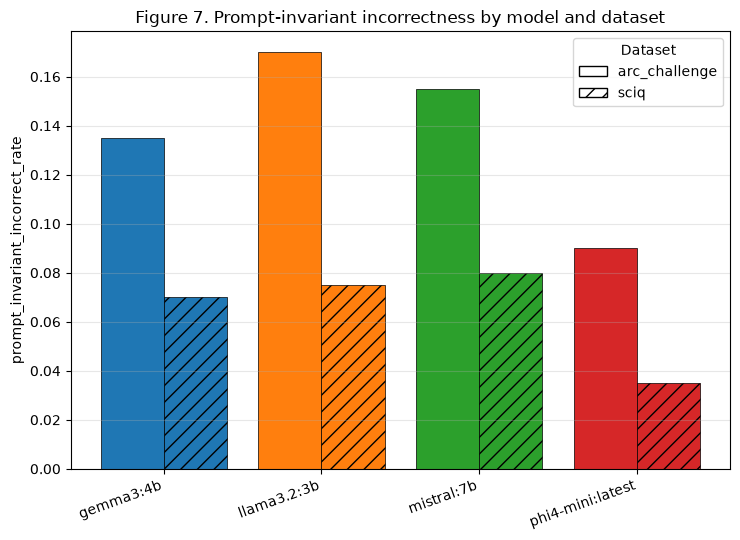

In [20]:

if df_model_dataset.empty or "prompt_invariant_incorrect_rate" not in df_model_dataset.columns:
    print("Skipping Figure 7: model_dataset_summary.csv or prompt_invariant_incorrect_rate not available.")
else:
    models = sorted(df_model_dataset["model"].unique())
    datasets = sorted(df_model_dataset["dataset"].unique())
    colors = model_colors(models)
    hatches = dataset_hatches(datasets)
    x = np.arange(len(models))
    bar_width = 0.8 / max(len(datasets), 1)

    fig, ax = plt.subplots(figsize=(7.5, 5.5))
    for j, ds in enumerate(datasets):
        sub = df_model_dataset[df_model_dataset["dataset"] == ds].set_index("model")
        vals = [sub["prompt_invariant_incorrect_rate"].get(m, np.nan) for m in models]
        offsets = x + (j - (len(datasets) - 1) / 2) * bar_width
        ax.bar(offsets, vals, width=bar_width, color=[colors[m] for m in models],
               edgecolor="black", linewidth=0.5, hatch=hatches[ds])

    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=20, ha="right")
    ax.set_ylabel("prompt_invariant_incorrect_rate")
    ax.set_title("Figure 7. Prompt-invariant incorrectness by model and dataset")
    ax.grid(axis="y", alpha=0.3)

    from matplotlib.patches import Patch
    dataset_handles = [Patch(facecolor="white", edgecolor="black", hatch=hatches[d], label=d) for d in datasets]
    ax.legend(handles=dataset_handles, title="Dataset")

    fig.tight_layout()
    save_fig(fig, "prompt_invariant_incorrectness.png")
    plt.show()


**Interpretation.** Higher bars mean a larger share of questions where the model is
consistently, unanimously wrong across all five prompt conditions — i.e., prompt reformulation
does not help. Combined with Figure 2 (accuracy vs. agreement), this distinguishes "consistent
and correct" models from "consistent but wrong" ones.


# 9. Cross-Dataset Comparison

**Level:** model/dataset aggregate (`model_dataset_summary.csv`).

Figure 9 compares each model across datasets on the full set of aggregate metrics, one small
panel per metric so that datasets are never combined or averaged together without being
labelled.


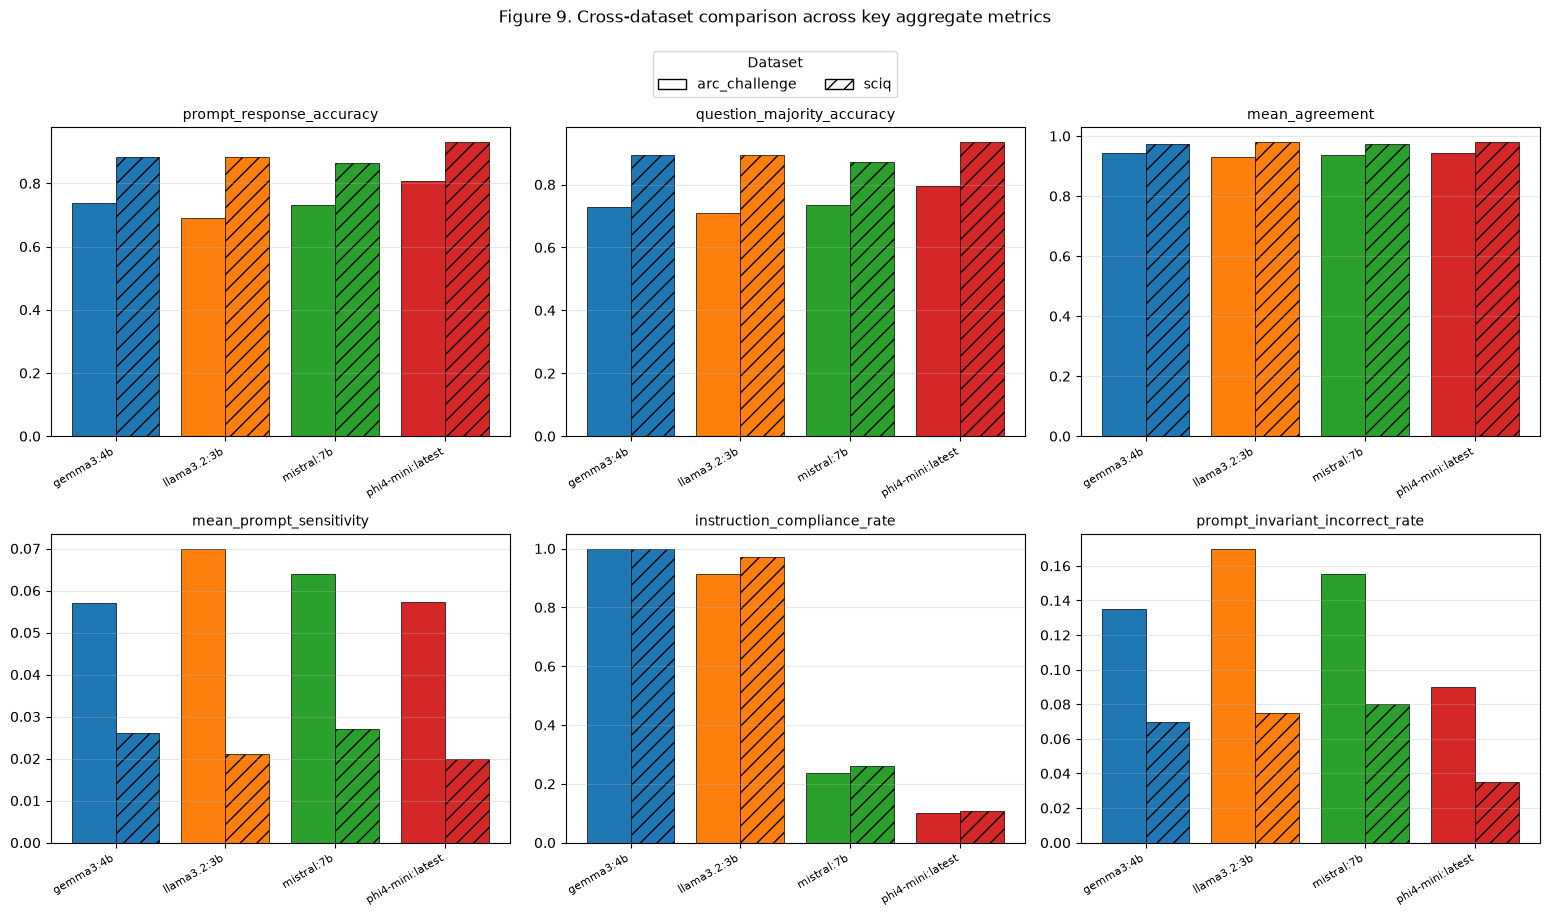

In [21]:

CROSS_DATASET_METRICS = [
    "prompt_response_accuracy", "question_majority_accuracy", "mean_agreement",
    "mean_prompt_sensitivity", "instruction_compliance_rate", "prompt_invariant_incorrect_rate",
]

if df_model_dataset.empty:
    print("Skipping Figure 9: model_dataset_summary.csv not available.")
else:
    available_metrics = [m for m in CROSS_DATASET_METRICS if m in df_model_dataset.columns]
    models = sorted(df_model_dataset["model"].unique())
    datasets = sorted(df_model_dataset["dataset"].unique())
    colors = model_colors(models)
    hatches = dataset_hatches(datasets)
    x = np.arange(len(models))
    bar_width = 0.8 / max(len(datasets), 1)

    n_cols = min(3, len(available_metrics)) if available_metrics else 1
    n_rows = math.ceil(len(available_metrics) / n_cols) if available_metrics else 1
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.2 * n_cols, 4.3 * n_rows), squeeze=False)

    for idx, metric in enumerate(available_metrics):
        r, c = divmod(idx, n_cols)
        ax = axes[r][c]
        for j, ds in enumerate(datasets):
            sub = df_model_dataset[df_model_dataset["dataset"] == ds].set_index("model")
            vals = [sub[metric].get(m, np.nan) for m in models]
            offsets = x + (j - (len(datasets) - 1) / 2) * bar_width
            ax.bar(offsets, vals, width=bar_width, color=[colors[m] for m in models],
                   edgecolor="black", linewidth=0.5, hatch=hatches[ds])
        ax.set_xticks(x)
        ax.set_xticklabels(models, rotation=30, ha="right", fontsize=8)
        ax.set_title(metric, fontsize=10)
        ax.grid(axis="y", alpha=0.3)

    for idx in range(len(available_metrics), n_rows * n_cols):
        r, c = divmod(idx, n_cols)
        axes[r][c].axis("off")

    from matplotlib.patches import Patch
    dataset_handles = [Patch(facecolor="white", edgecolor="black", hatch=hatches[d], label=d) for d in datasets]
    fig.legend(handles=dataset_handles, title="Dataset", loc="upper center", ncol=len(datasets),
               bbox_to_anchor=(0.5, 1.02))
    fig.suptitle("Figure 9. Cross-dataset comparison across key aggregate metrics", y=1.06)
    fig.tight_layout()
    save_fig(fig, "dataset_comparison.png")
    plt.show()


**Interpretation.** Each small panel shows one aggregate metric, with bars split by
dataset (hatch pattern) and colored by model. Systematic differences between datasets for the
same model (e.g., consistently lower accuracy or higher prompt sensitivity on one dataset)
suggest that dataset difficulty or question style affects behavior, though this notebook does
not attempt to explain *why* — only *whether and how much* the metrics differ, descriptively.


# 10. Question-Level Analysis

**Level:** question-level (`*_question_metrics.jsonl`).

Each question is classified into one of five PRISM behavioral categories, using only fields
already present in the question-level records (no metric is recomputed):

- **Unrecoverable** — no usable recovered answer for the question
  (`valid_response_count == 0`, i.e. no prompt condition yielded an A/B/C/D answer).
- **Consistent + Correct** — the recovered answer is unanimous across prompt conditions
  (`answer_unanimous == True`) and the majority answer is correct (`majority_correct == True`).
- **Consistent + Incorrect** — unanimous recovered answer (`answer_unanimous == True`) but the
  majority answer is incorrect (`majority_correct == False`).
- **Prompt-Sensitive + Majority Correct** — recovered answers are *not* unanimous
  (`answer_unanimous == False`) but the majority answer is still correct
  (`majority_correct == True`).
- **Prompt-Sensitive + Majority Incorrect** — recovered answers are not unanimous
  (`answer_unanimous == False`) and the majority answer is incorrect
  (`majority_correct == False`).

The `Unrecoverable` check is applied first and takes precedence over the other four categories.


In [22]:

def classify_question(row):
    valid_count = row.get("valid_response_count")
    if pd.isna(valid_count) or valid_count == 0:
        return "Unrecoverable"

    unanimous = row.get("answer_unanimous")
    correct = row.get("majority_correct")
    if pd.isna(unanimous) or pd.isna(correct):
        return "Unrecoverable"

    if unanimous:
        return "Consistent + Correct" if correct else "Consistent + Incorrect"
    else:
        return "Prompt-Sensitive + Majority Correct" if correct else "Prompt-Sensitive + Majority Incorrect"

CATEGORY_ORDER = [
    "Consistent + Correct",
    "Consistent + Incorrect",
    "Prompt-Sensitive + Majority Correct",
    "Prompt-Sensitive + Majority Incorrect",
    "Unrecoverable",
]

if df_question.empty:
    print("Skipping question-level classification: no question-level records loaded.")
else:
    required = {"valid_response_count", "answer_unanimous", "majority_correct"}
    missing = required - set(df_question.columns)
    if missing:
        print(f"Cannot classify questions; missing fields: {missing}")
    else:
        df_question["prism_category"] = df_question.apply(classify_question, axis=1)
        print(df_question["prism_category"].value_counts().reindex(CATEGORY_ORDER, fill_value=0))


prism_category
Consistent + Correct                     1194
Consistent + Incorrect                    162
Prompt-Sensitive + Majority Correct       119
Prompt-Sensitive + Majority Incorrect     125
Unrecoverable                               0
Name: count, dtype: int64


In [ ]:

if df_question.empty or "prism_category" not in df_question.columns:
    print("Skipping Figure 10: question-level classification not available.")
else:
    combos = sorted(df_question.groupby(["model", "dataset"]).groups.keys())
    cat_colors = {
        "Consistent + Correct": "#2ca02c",
        "Consistent + Incorrect": "#d62728",
        "Prompt-Sensitive + Majority Correct": "#1f77b4",
        "Prompt-Sensitive + Majority Incorrect": "#ff7f0e",
        "Unrecoverable": "#7f7f7f",
    }

    proportions = []
    labels = []
    for m, d in combos:
        sub = df_question[(df_question["model"] == m) & (df_question["dataset"] == d)]
        counts = sub["prism_category"].value_counts().reindex(CATEGORY_ORDER, fill_value=0)
        props = counts / counts.sum() if counts.sum() > 0 else counts.astype(float)
        proportions.append(props)
        labels.append(f"{m}\n{d}")

    fig, ax = plt.subplots(figsize=(max(7, 1.3 * len(combos)), 6))
    bottom = np.zeros(len(combos))
    for cat in CATEGORY_ORDER:
        vals = np.array([p[cat] for p in proportions])
        ax.bar(labels, vals, bottom=bottom, label=cat, color=cat_colors[cat], edgecolor="black", linewidth=0.4)
        bottom += vals

    ax.set_ylabel("Proportion of questions")
    ax.set_ylim(0, 1.05)
    ax.set_title("Figure 10. PRISM behavioral category proportions, by model and dataset")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    save_fig(fig, "prism_behavioral_categories.png")
    plt.show()


**Interpretation.** Each stacked bar sums to 1.0 (or is empty for a `model/dataset` combo
with no records) and shows the mix of behavioral categories for that model on that dataset.
A large green (Consistent + Correct) share is the best outcome; a large red (Consistent +
Incorrect) share flags prompt-invariant errors specifically at the per-question level
(consistent with, but more granular than, `prompt_invariant_incorrect_rate` in Section 8).
Orange/blue slices show how much of the remaining behavior is prompt-sensitive, and whether
that sensitivity more often resolves toward a correct or incorrect majority answer.


### Representative question examples (Figure 11)

One concrete, actual example per category is shown below, drawn directly from the loaded
question-level records (no example is fabricated or synthesized). If a category has no
matching question in the loaded data, that is stated explicitly instead of substituting a
placeholder.


In [23]:

DISPLAY_FIELDS = ["question_id", "model", "dataset", "expected_answer"]

def format_example(row):
    resp = row.get("responses") if isinstance(row.get("responses"), dict) else {}
    out = {f: row.get(f) for f in DISPLAY_FIELDS}
    for p in PROMPT_CONDITIONS:
        out[p] = resp.get(p, None)
    out["majority_answer"] = row.get("majority_answer")
    out["agreement"] = row.get("agreement")
    out["prompt_sensitivity"] = row.get("prompt_sensitivity")
    out["answer_unanimous"] = row.get("answer_unanimous")
    out["majority_correct"] = row.get("majority_correct")
    return out

if df_question.empty or "prism_category" not in df_question.columns:
    print("Skipping Figure 11: question-level classification not available.")
else:
    examples = []
    for cat in CATEGORY_ORDER:
        matches = df_question[df_question["prism_category"] == cat]
        if matches.empty:
            print(f"No example available in the loaded data for category: {cat}")
            continue
        chosen = matches.iloc[0]
        examples.append(format_example(chosen))

    if examples:
        df_examples = pd.DataFrame(examples)
        display(df_examples)
    else:
        print("No representative examples could be selected from the loaded data.")


No example available in the loaded data for category: Unrecoverable


,question_id,model,dataset,expected_answer,P0,P1,P2,P3,P4,majority_answer,agreement,prompt_sensitivity,answer_unanimous,majority_correct
0,ACTAAP_2009_7_8,gemma3:4b,arc_challenge,D,D,D,D,D,D,D,1.0,0.0,True,True
1,CSZ20754,gemma3:4b,arc_challenge,B,C,C,C,C,C,C,1.0,0.0,True,False
2,MCAS_2005_9_6,gemma3:4b,arc_challenge,C,C,C,B,C,C,C,0.8,0.2,False,True
3,AKDE&ED_2008_4_25,gemma3:4b,arc_challenge,A,D,D,D,A,D,D,0.8,0.2,False,False


# 11. Key Observations

The observations below are generated programmatically from the actual loaded data (they will
change if the underlying result files change). They are descriptive: they report which
model/dataset combinations rank highest or lowest on each metric, without asserting a causal
explanation, and without claiming statistical significance (no significance test is run in this
notebook).


In [24]:

def fmt_pct(x):
    return "n/a" if pd.isna(x) else f"{x:.1%}"

observations = []

if df_model_dataset.empty:
    observations.append("No model_dataset_summary.csv was available, so aggregate accuracy, "
                         "agreement, sensitivity, compliance, and prompt-invariant-incorrectness "
                         "observations could not be generated.")
else:
    d = df_model_dataset.copy()
    d["label"] = d["model"].astype(str) + " / " + d["dataset"].astype(str)

    def top_bottom(metric, higher_is_better=True):
        sub = d.dropna(subset=[metric])
        if sub.empty:
            return None
        top = sub.loc[sub[metric].idxmax()]
        bot = sub.loc[sub[metric].idxmin()]
        return top, bot

    tb = top_bottom("prompt_response_accuracy")
    if tb:
        top, bot = tb
        observations.append(
            f"**Accuracy (prompt_response_accuracy):** highest for {top['label']} "
            f"({fmt_pct(top['prompt_response_accuracy'])}); lowest for {bot['label']} "
            f"({fmt_pct(bot['prompt_response_accuracy'])})."
        )

    tb = top_bottom("mean_agreement")
    if tb:
        top, bot = tb
        observations.append(
            f"**Agreement (mean_agreement):** highest for {top['label']} "
            f"({top['mean_agreement']:.3f}); lowest for {bot['label']} "
            f"({bot['mean_agreement']:.3f})."
        )

    tb = top_bottom("mean_prompt_sensitivity")
    if tb:
        top, bot = tb
        observations.append(
            f"**Prompt sensitivity (mean_prompt_sensitivity):** highest (most sensitive) for "
            f"{top['label']} ({top['mean_prompt_sensitivity']:.3f}); lowest (least sensitive) "
            f"for {bot['label']} ({bot['mean_prompt_sensitivity']:.3f})."
        )

    tb = top_bottom("instruction_compliance_rate")
    if tb:
        top, bot = tb
        observations.append(
            f"**Instruction compliance:** highest for {top['label']} "
            f"({fmt_pct(top['instruction_compliance_rate'])}); lowest for {bot['label']} "
            f"({fmt_pct(bot['instruction_compliance_rate'])}). "
            "This reflects adherence to the required output format only, not correctness."
        )

    tb = top_bottom("prompt_invariant_incorrect_rate")
    if tb:
        top, bot = tb
        observations.append(
            f"**Prompt-invariant incorrectness:** highest for {top['label']} "
            f"({fmt_pct(top['prompt_invariant_incorrect_rate'])}), meaning this model/dataset "
            f"combination most often lands on the same wrong answer regardless of prompt "
            f"phrasing; lowest for {bot['label']} "
            f"({fmt_pct(bot['prompt_invariant_incorrect_rate'])})."
        )

    # ARC vs SciQ style comparison: per-model differences across datasets, where >=2 datasets exist
    datasets_present = sorted(d["dataset"].unique())
    if len(datasets_present) >= 2:
        pivot = d.pivot_table(index="model", columns="dataset", values="prompt_response_accuracy")
        pivot = pivot.dropna()
        if not pivot.empty:
            diffs = (pivot[datasets_present[0]] - pivot[datasets_present[1]])
            biggest = diffs.abs().idxmax()
            observations.append(
                f"**Dataset comparison ({datasets_present[0]} vs {datasets_present[1]}):** the "
                f"largest prompt_response_accuracy gap between the two datasets, for the same "
                f"model, is for '{biggest}' "
                f"({fmt_pct(pivot.loc[biggest, datasets_present[0]])} vs "
                f"{fmt_pct(pivot.loc[biggest, datasets_present[1]])})."
            )
    else:
        observations.append("Only one dataset was present in the loaded data, so no "
                             "cross-dataset comparison could be generated.")

    # Consistency vs correctness: descriptive correlation only, no significance claim.
    sub = d.dropna(subset=["mean_agreement", "prompt_response_accuracy"])
    if len(sub) >= 3:
        corr = np.corrcoef(sub["mean_agreement"], sub["prompt_response_accuracy"])[0, 1]
        direction = "positively associated" if corr > 0.1 else ("negatively associated" if corr < -0.1 else "not clearly associated")
        observations.append(
            f"**Consistency vs. correctness:** across the {len(sub)} model/dataset combinations "
            f"loaded, mean_agreement and prompt_response_accuracy are {direction} in this data "
            f"(Pearson r = {corr:.2f}). This is a descriptive statistic over a small number of "
            f"points, not a hypothesis test, and should not be read as a significance claim. "
            f"The prompt-invariant-incorrectness figures above should be consulted directly to "
            f"see whether specific models are consistent while still being wrong."
        )
    elif not sub.empty:
        observations.append(
            "**Consistency vs. correctness:** too few model/dataset combinations with both "
            "mean_agreement and prompt_response_accuracy were available to compute a "
            "meaningful descriptive correlation."
        )

if df_question.empty or "prism_category" not in df_question.columns:
    observations.append("Question-level PRISM behavioral categories were not available, so no "
                         "observation about consistent-but-wrong questions at the question "
                         "level could be generated beyond the aggregate "
                         "prompt_invariant_incorrect_rate above.")
else:
    cat_counts = df_question["prism_category"].value_counts()
    total = cat_counts.sum()
    if total > 0:
        ci_share = cat_counts.get("Consistent + Incorrect", 0) / total
        cc_share = cat_counts.get("Consistent + Correct", 0) / total
        observations.append(
            f"**Question-level behavior:** across all loaded questions, "
            f"{fmt_pct(cc_share)} are Consistent + Correct and {fmt_pct(ci_share)} are "
            f"Consistent + Incorrect, i.e. a non-trivial share of consistent behavior can "
            f"still be consistently wrong rather than consistently right."
        )

print("Key Observations")
print("=" * 70)
for i, obs in enumerate(observations, 1):
    print(f"{i}. {obs}\n")


Key Observations
1. **Accuracy (prompt_response_accuracy):** highest for phi4-mini:latest / sciq (93.1%); lowest for llama3.2:3b / arc_challenge (69.0%).

2. **Agreement (mean_agreement):** highest for phi4-mini:latest / sciq (0.980); lowest for llama3.2:3b / arc_challenge (0.930).

3. **Prompt sensitivity (mean_prompt_sensitivity):** highest (most sensitive) for llama3.2:3b / arc_challenge (0.070); lowest (least sensitive) for phi4-mini:latest / sciq (0.020).

4. **Instruction compliance:** highest for gemma3:4b / arc_challenge (100.0%); lowest for phi4-mini:latest / arc_challenge (10.1%). This reflects adherence to the required output format only, not correctness.

5. **Prompt-invariant incorrectness:** highest for llama3.2:3b / arc_challenge (17.0%), meaning this model/dataset combination most often lands on the same wrong answer regardless of prompt phrasing; lowest for phi4-mini:latest / sciq (3.5%).

6. **Dataset comparison (arc_challenge vs sciq):** the largest prompt_response_a